Caso: análisis exploratorio - EXPOANDINA

## Acerca del conjunto de datos

 **Contexto.**

Este dataset contiene información sobre la notificación de casos de malaria al sistema de vigilancia en salud pública del Perú, gestionado y administrado por el Centro Nacional de Epidemiología, Prevención y Control de Enfermedades (CDC PERU). Los datos provienen de la Red Nacional de Epidemiología (RENACE), que está conformada por 10 034 establecimientos de salud del Ministerio de Salud, EsSalud y otros del sector en los diferentes niveles de las Direcciones Regionales de Salud que tiene el Perú. De estos, 8 105 son Unidades Notificantes, reconocidos con Resolución Directoral de las respectivas Diresas/Geresas de Salud del Perú. La información del dataset se actualiza cada semana o mes, según la sección de tendencia del boletín epidemiológico, y es suministrada semanalmente por la RENACE. Los datos y análisis son provisionales y pueden estar sujetos a modificación. El dataset tiene como objetivo proporcionar información sobre la situación epidemiológica del dengue en el Perú, así como facilitar el acceso a los datos abiertos para fines de investigación, educación, prevención y control de esta enfermedad.

El dataset contempla una serie histórica del 2000 al 2022, con datos desagregados por departamento, provincia, distrito, enfermedad, año, semana, diagnóstico, tipo de diagnóstico, dirección de salud, ubigeo, edad, tipo de edad y sexo. El dataset incluye las siguientes variables:

Se puede descargar gratuitamente aquí: https://www.datosabiertos.gob.pe/dataset/vigilancia-epidemiol%C3%B3gica-de-malaria

### Objetivo de estudio:

El objetivo de tu proyecto, basado en la descripción del dataset, sería predecir brotes de malaria en Perú para el año 2027 utilizando técnicas de machine learning. Predecir brotes de malaria en Perú para el año 2027 utilizando modelos de machine learning basados en datos históricos de notificación de casos de malaria proporcionados por el sistema de vigilancia en salud pública del Perú (RENACE).


#####  Análisis Exploratorio de Datos (EDA):

Explorar y analizar la serie histórica de datos de malaria desde el año 2000 hasta el 2022.
Identificar patrones, tendencias y correlaciones entre las variables del dataset.
##### Preprocesamiento de Datos:

Limpiar y preparar los datos para el modelado, incluyendo la gestión de valores faltantes, outliers y la codificación de variables categóricas.
Realizar la normalización o estandarización de los datos según sea necesario.
#####  Selección y Creación de Features:

Identificar y seleccionar las características más relevantes para la predicción de brotes de malaria.
Crear nuevas variables derivadas que puedan mejorar el rendimiento del modelo.

Los atributos de esta dataset son:

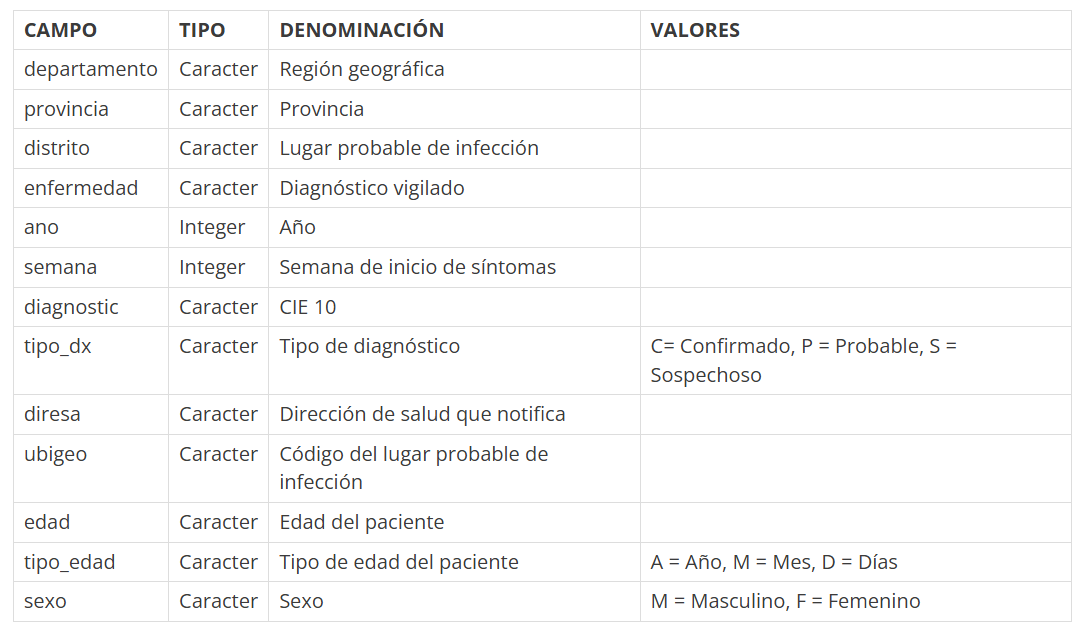
Contenido:
1. Load and Check Data
1. Data Visualization
1. Feature Engineering

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow.compat.v1 as tf
#tf.disable_v2_behavior()

In [ ]:
#Importación de paquetes

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns



from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder,MinMaxScaler

from keras.utils import to_categorical
import tensorflow as tf
from tensorflow import keras


##**1. Load and Check Data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Trabajo  Final de inteligencia de negocios/Data de panel/datos_abiertos_vigilancia_malaria.csv',
                         encoding="latin-1")

<ipython-input-5-1883f499f501>:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Trabajo  Final de inteligencia de negocios/Data de panel/datos_abiertos_vigilancia_malaria.csv',


In [ ]:
df.head()

,departamento,provincia,distrito,localidad,enfermedad,ano,semana,diagnostic,diresa,ubigeo,localcod,edad,tipo_edad,sexo
0,ANCASH,HUARMEY,HUARMEY,NaN,MALARIA P. FALCIPARUM,2000,6,B50,2,21101,NaN,2,A,M
1,ANCASH,HUARMEY,HUARMEY,NaN,MALARIA P. FALCIPARUM,2000,7,B50,2,21101,NaN,36,A,M
2,ANCASH,HUARMEY,HUARMEY,NaN,MALARIA P. FALCIPARUM,2000,15,B50,2,21101,NaN,7,M,F
3,ANCASH,RECUAY,PARARIN,NaN,MALARIA P. FALCIPARUM,2000,12,B50,2,21708,NaN,23,A,M
4,AYACUCHO,LA MAR,SAN MIGUEL,NaN,MALARIA P. FALCIPARUM,2000,16,B50,5,50501,NaN,17,A,M


In [ ]:
df.shape

(604968, 14)

In [ ]:
df.dtypes

departamento    object
provincia       object
distrito        object
localidad       object
enfermedad      object
ano              int64
semana           int64
diagnostic      object
diresa           int64
ubigeo           int64
localcod        object
edad             int64
tipo_edad       object
sexo            object
dtype: object

In [ ]:
df["departamento"].unique()

array(['ANCASH', 'AYACUCHO', 'HUANUCO', 'LIMA', 'PIURA', 'TUMBES',
       'AMAZONAS', 'LORETO', 'JUNIN', 'APURIMAC', 'PASCO', 'LA LIBERTAD',
       'UCAYALI', 'LAMBAYEQUE', 'SAN MARTIN', 'CAJAMARCA',
       'MADRE DE DIOS', 'CUSCO', '\\N', 'HUANCAVELICA', 'AREQUIPA',
       'PUNO'], dtype=object)

In [ ]:
df["enfermedad"].unique()

array(['MALARIA P. FALCIPARUM', 'MALARIA POR P. VIVAX'], dtype=object)

In [ ]:
df["ano"].unique()

array([2000, 2001, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2015, 2014, 2016, 2017, 2002, 2018, 2019, 2020, 2021,
       2022])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 604968 entries, 0 to 604967
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   departamento  604968 non-null  object
 1   provincia     604968 non-null  object
 2   distrito      604968 non-null  object
 3   localidad     544311 non-null  object
 4   enfermedad    604968 non-null  object
 5   ano           604968 non-null  int64 
 6   semana        604968 non-null  int64 
 7   diagnostic    604968 non-null  object
 8   diresa        604968 non-null  int64 
 9   ubigeo        604968 non-null  int64 
 10  localcod      547199 non-null  object
 11  edad          604968 non-null  int64 
 12  tipo_edad     604968 non-null  object
 13  sexo          604968 non-null  object
dtypes: int64(5), object(9)
memory usage: 64.6+ MB


In [ ]:
def tasaDatosAusentes(df):
    rate = df.isnull().sum()/df.shape[0]
    return(rate)

In [ ]:
tasaDatosAusentes(df)

departamento    0.000000
provincia       0.000000
distrito        0.000000
localidad       0.100265
enfermedad      0.000000
ano             0.000000
semana          0.000000
diagnostic      0.000000
diresa          0.000000
ubigeo          0.000000
localcod        0.095491
edad            0.000000
tipo_edad       0.000000
sexo            0.000000
dtype: float64

In [ ]:
df.nunique()

departamento      22
provincia        112
distrito         425
localidad       3976
enfermedad         2
ano               23
semana            53
diagnostic         2
diresa            31
ubigeo           442
localcod        8689
edad             150
tipo_edad          3
sexo               2
dtype: int64

In [ ]:
df["departamento"].nunique()

22

In [ ]:
df["provincia"].nunique()

112

In [ ]:
def atributosVarianzaNula(df):
    counts = df.nunique()
    counts = pd.DataFrame(counts).reset_index().rename(columns={'index': 'feature', 0: 'count'})
    return list(counts[counts['count'] == 1]['feature'])

In [ ]:
print(atributosVarianzaNula(df))

[]


In [ ]:
df['semana'].describe()

count    604968.000000
mean         26.033311
std          14.149839
min           1.000000
25%          14.000000
50%          26.000000
75%          38.000000
max          53.000000
Name: semana, dtype: float64

In [ ]:
df.describe()

,ano,semana,diresa,ubigeo,edad
count,604968.000000,604968.000000,604968.000000,604968.000000,6.049680e+05
mean,2014.045181,26.033311,16.435529,157326.320921,2.051882e+03
std,4.538514,14.149839,4.883595,43076.088468,3.690761e+05
min,2000.000000,1.000000,2.000000,10101.000000,1.000000e+00
25%,2011.000000,14.000000,16.000000,160107.000000,7.000000e+00
50%,2015.000000,26.000000,16.000000,160303.000000,1.600000e+01
75%,2017.000000,38.000000,16.000000,160703.000000,3.100000e+01
max,2022.000000,53.000000,99.000000,999999.000000,9.013030e+07


In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ano,604968.0,2014.045181,4.538514,2000.0,2011.0,2015.0,2017.0,2022.0
semana,604968.0,26.033311,14.149839,1.0,14.0,26.0,38.0,53.0
diresa,604968.0,16.435529,4.883595,2.0,16.0,16.0,16.0,99.0
ubigeo,604968.0,157326.320921,43076.088468,10101.0,160107.0,160303.0,160703.0,999999.0
edad,604968.0,2051.882195,369076.133450,1.0,7.0,16.0,31.0,90130297.0


In [ ]:
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
departamento,604968,22,LORETO,517816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
provincia,604968,112,MAYNAS,194413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
distrito,604968,425,ANDOAS,67634,NaN,NaN,NaN,NaN,NaN,NaN,NaN
localidad,544311,3976,NAUTA,9644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
enfermedad,604968,2,MALARIA POR P. VIVAX,444092,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ano,604968.0,NaN,NaN,NaN,2014.045181,4.538514,2000.0,2011.0,2015.0,2017.0,2022.0
semana,604968.0,NaN,NaN,NaN,26.033311,14.149839,1.0,14.0,26.0,38.0,53.0
diagnostic,604968,2,B51,444092,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diresa,604968.0,NaN,NaN,NaN,16.435529,4.883595,2.0,16.0,16.0,16.0,99.0
ubigeo,604968.0,NaN,NaN,NaN,157326.320921,43076.088468,10101.0,160107.0,160303.0,160703.0,999999.0


In [ ]:
df['semana'].max()

53

In [ ]:
df['semana'].min()

1

In [ ]:
df['semana'].mean()

26.03331085280544

In [ ]:
df['semana'].std()

14.14983911434653

In [ ]:
df['semana'].sum()

15749320

In [ ]:
df['ano'].value_counts()

ano
2014    65279
2015    63292
2016    56565
2017    55283
2013    48934
2018    45614
2009    36895
2012    31724
2010    29355
2022    27080
2019    24493
2011    23075
2021    18139
2020    15835
2005    15091
2004    13802
2003    13706
2006     8344
2007     7791
2008     4529
2000       73
2001       62
2002        7
Name: count, dtype: int64

In [ ]:
df.isnull().sum()

departamento        0
provincia           0
distrito            0
localidad       60657
enfermedad          0
ano                 0
semana              0
diagnostic          0
diresa              0
ubigeo              0
localcod        57769
edad                0
tipo_edad           0
sexo                0
dtype: int64

In [ ]:
df[['ano','semana']].groupby('ano').mean()

,semana
ano,
2000,18.630137
2001,23.774194
2002,37.285714
2003,24.771779
2004,24.171207
2005,24.796567
2006,23.473274
2007,23.970607
2008,25.815633


In [ ]:
df.groupby('diresa').describe()

ano                                                           \
           count         mean        std     min     25%     50%      75%   
diresa                                                                      
2           29.0  2007.241379   4.733280  2000.0  2001.0  2009.0  2009.00   
4            1.0  2016.000000        NaN  2016.0  2016.0  2016.0  2016.00   
5         8882.0  2011.883134   1.772588  2000.0  2011.0  2012.0  2013.00   
8         4898.0  2012.738465   3.299927  2009.0  2010.0  2012.0  2014.00   
9           14.0  2011.642857   3.387923  2009.0  2010.0  2010.0  2012.50   
10          35.0  2010.514286   5.617051  2000.0  2009.0  2011.0  2013.00   
12       26924.0  2013.198002   4.125368  2000.0  2010.0  2011.0  2015.00   
13        1608.0  2011.976990   4.181042  2000.0  2009.0  2011.0  2016.00   
14         593.0  2008.311973   2.597844  2001.0  2009.0  2009.0  2009.00   
16      517818.0  2014.400620   4.401411  2000.0  2013.0  2015.0  2017.00   
17        7969.0  2010.294767   1.299646  2004.0  2009.0  2010.0  2011.00   
19         892.0  2011.604260   1.116806  2000.0  2011.0  2012.0  2012.00   
21           3.0  2018.000000   1.000000  2017.0  2017.5  2018.0  2018.50   
22       10452.0  2008.555205   5.632454  2001.0  2004.0  2005.0  2014.00   
24        4970.0  2009.221529   3.040119  2000.0  2009.0  2010.0  2010.00   
25        2424.0  2008.208333   5.337313  2000.0  2003.0  2006.0  2012.00   
31        5115.0  2009.472336   1.063752  2001.0  2009.0  2009.0  2010.00   
32         184.0  2009.239130   2.915456  2000.0  2009.0  2009.0  2010.00   
33          17.0  2011.823529   3.468344  2007.0  2010.0  2011.0  2012.00   
34          12.0  2009.000000   3.219260  2000.0  2009.0  2009.0  2009.25   
35         308.0  2011.081169   5.811079  2003.0  2004.0  2011.0  2016.00   
36        9835.0  2017.226436   5.164891  2000.0  2016.0  2019.0  2020.00   
37           5.0  2008.200000   4.266146  2004.0  2004.0  2009.0  2010.00   
38        1020.0  2005.448039   2.137622  2003.0  2004.0  2005.0  2005.00   
42          54.0  2000.870370   2.449846  2000.0  2000.0  2000.0  2001.00   
46          10.0  2007.900000   3.900142  2003.0  2006.0  2006.0  2009.00   
48          21.0  2010.476190   2.293884  2009.0  2009.0  2010.0  2010.00   
51           2.0  2019.000000   1.414214  2018.0  2018.5  2019.0  2019.50   
52           3.0  2012.000000  10.392305  2000.0  2009.0  2018.0  2018.00   
53           4.0  2009.500000  10.969655  2000.0  2000.0  2009.5  2019.00   
99         866.0  2017.108545   3.024715  2009.0  2015.0  2018.0  2019.00   

                  semana             ...     ubigeo                edad  \
           max     count       mean  ...        75%       max     count   
diresa                               ...                                  
2       2019.0      29.0  19.275862  ...   21805.00   22006.0      29.0   
4       2016.0       1.0  10.000000  ...   40103.00   40103.0       1.0   
5       2022.0    8882.0  28.468250  ...   50502.00   51104.0    8882.0   
8       2022.0    4898.0  27.279706  ...   80910.00   81303.0    4898.0   
9       2020.0      14.0  23.000000  ...   90717.00   90718.0      14.0   
10      2019.0      35.0  25.571429  ...  100901.50  160304.0      35.0   
12      2022.0   26924.0  26.310838  ...  120608.00  120609.0   26924.0   
13      2022.0    1608.0  23.643657  ...  130908.00  160113.0    1608.0   
14      2016.0     593.0  21.269815  ...  140310.00  220901.0     593.0   
16      2022.0  517818.0  26.186135  ...  160511.00  220901.0  517818.0   
17      2020.0    7969.0  22.405321  ...  170204.00  170303.0    7969.0   
19      2017.0     892.0  40.901345  ...  190306.00  250101.0     892.0   
21      2019.0       3.0  21.333333  ...  211210.00  211210.0       3.0   
22      2022.0   10452.0  23.980195  ...  220804.00  221005.0   10452.0   
24      2021.0    4970.0  21.584507  ...  240301.00  240304.0    4970.0   
25      2022.0    2424.0  25.477310  ...  25

In [ ]:
top_5 = df.sort_values(by="ano", ascending=False).head().transpose()
top_5

,604967,586931,586907,586908,586909
departamento,LORETO,JUNIN,JUNIN,LORETO,JUNIN
provincia,MAYNAS,SATIPO,SATIPO,ALTO AMAZONAS,SATIPO
distrito,FERNANDO LORES,RIO TAMBO,RIO TAMBO,BALSAPUERTO,RIO TAMBO
localidad,TAMSHIYACU,SHAMPINTIARI,CUTIVIRENI,ANTIOQUIA,CUTIVIRENI
enfermedad,MALARIA POR P. VIVAX,MALARIA POR P. VIVAX,MALARIA POR P. VIVAX,MALARIA POR P. VIVAX,MALARIA POR P. VIVAX
ano,2022,2022,2022,2022,2022
semana,52,20,20,20,20
diagnostic,B51,B51,B51,B51,B51
diresa,16,12,12,16,12
ubigeo,160103,120608,120608,160202,120608


In [ ]:
df.head()

,departamento,provincia,distrito,localidad,enfermedad,ano,semana,diagnostic,diresa,ubigeo,localcod,edad,tipo_edad,sexo
0,ANCASH,HUARMEY,HUARMEY,NaN,MALARIA P. FALCIPARUM,2000,6,B50,2,21101,NaN,2,A,M
1,ANCASH,HUARMEY,HUARMEY,NaN,MALARIA P. FALCIPARUM,2000,7,B50,2,21101,NaN,36,A,M
2,ANCASH,HUARMEY,HUARMEY,NaN,MALARIA P. FALCIPARUM,2000,15,B50,2,21101,NaN,7,M,F
3,ANCASH,RECUAY,PARARIN,NaN,MALARIA P. FALCIPARUM,2000,12,B50,2,21708,NaN,23,A,M
4,AYACUCHO,LA MAR,SAN MIGUEL,NaN,MALARIA P. FALCIPARUM,2000,16,B50,5,50501,NaN,17,A,M


##**2. Data Visualization**

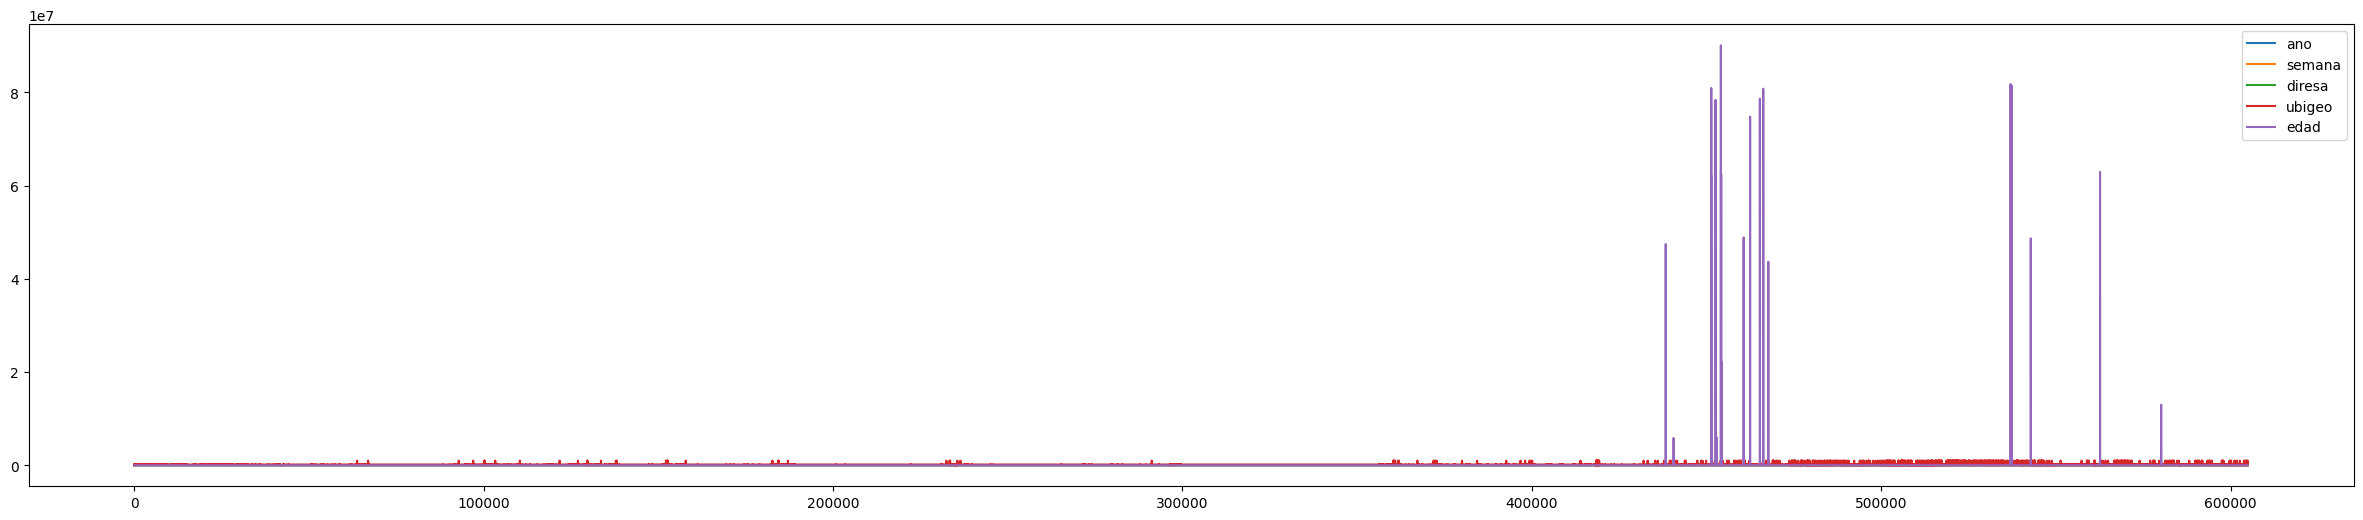

In [ ]:
df.plot(figsize=(30, 6))
plt.show()

<Axes: >

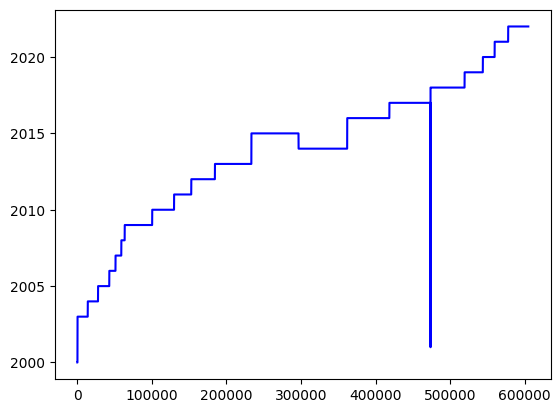

In [ ]:
df.ano.plot(color='blue')

<Axes: >

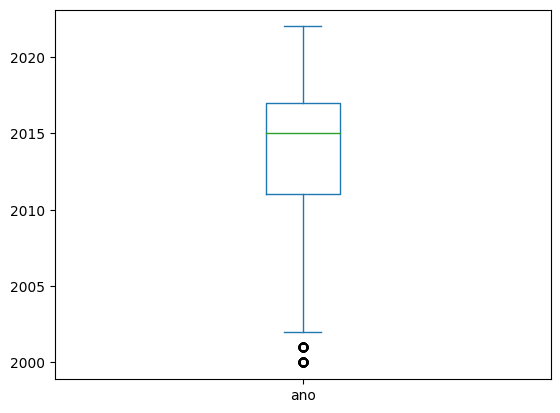

In [ ]:
df['ano'].plot(kind='box')

<Axes: >

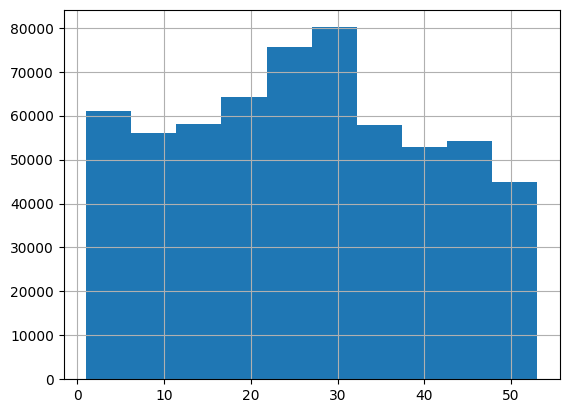

In [ ]:
df['semana'].hist()

In [ ]:
semana = df.groupby('semana').semana.count().sort_values(ascending=False)
semana

semana
24    15840
23    15783
27    15714
22    14984
25    14614
26    14469
21    14467
28    14450
20    13717
29    13509
31    12847
19    12452
18    12339
36    12203
33    12137
16    12130
11    11905
14    11862
30    11853
37    11839
12    11828
46    11742
32    11741
45    11528
15    11446
17    11303
10    11243
41    11242
9     11159
7     11051
34    10875
13    10868
35    10784
42    10675
38    10640
47    10633
8     10588
6     10578
1     10380
43    10288
40    10270
5     10268
3     10267
48    10237
49    10133
44    10100
39    10039
2      9846
4      9646
50     9599
51     7377
52     6339
53     1141
Name: semana, dtype: int64

In [ ]:
año = df.groupby('ano').ano.count().sort_values(ascending=False)
año

ano
2014    65279
2015    63292
2016    56565
2017    55283
2013    48934
2018    45614
2009    36895
2012    31724
2010    29355
2022    27080
2019    24493
2011    23075
2021    18139
2020    15835
2005    15091
2004    13802
2003    13706
2006     8344
2007     7791
2008     4529
2000       73
2001       62
2002        7
Name: ano, dtype: int64

<Axes: ylabel='ano'>

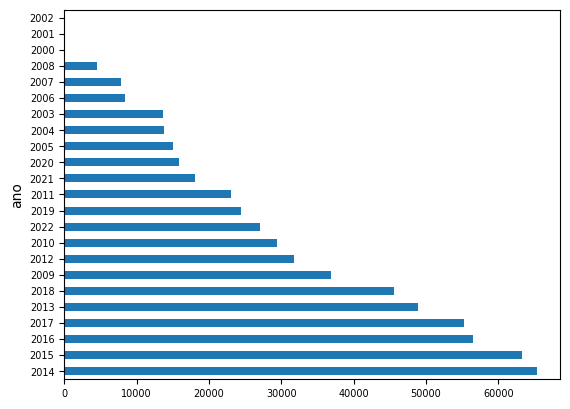

In [ ]:
año.plot(kind="barh", fontsize=7)

<Axes: >

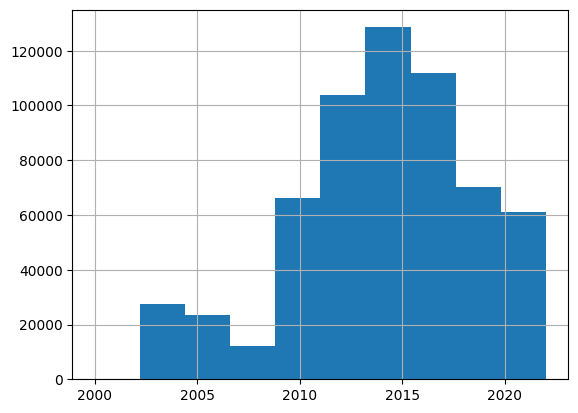

In [ ]:
df['ano'].hist()

<Axes: >

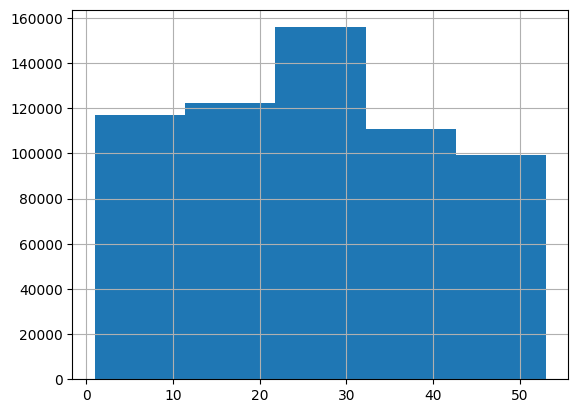

In [ ]:
df.semana.hist(bins=5)

<Axes: xlabel='enfermedad', ylabel='ano'>

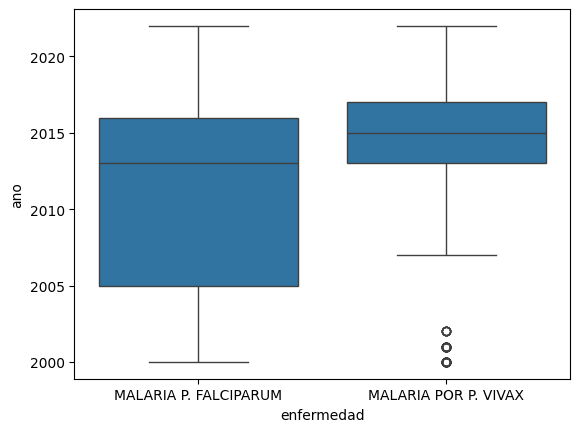

In [ ]:
sns.boxplot(x='enfermedad', y='ano', data=df)

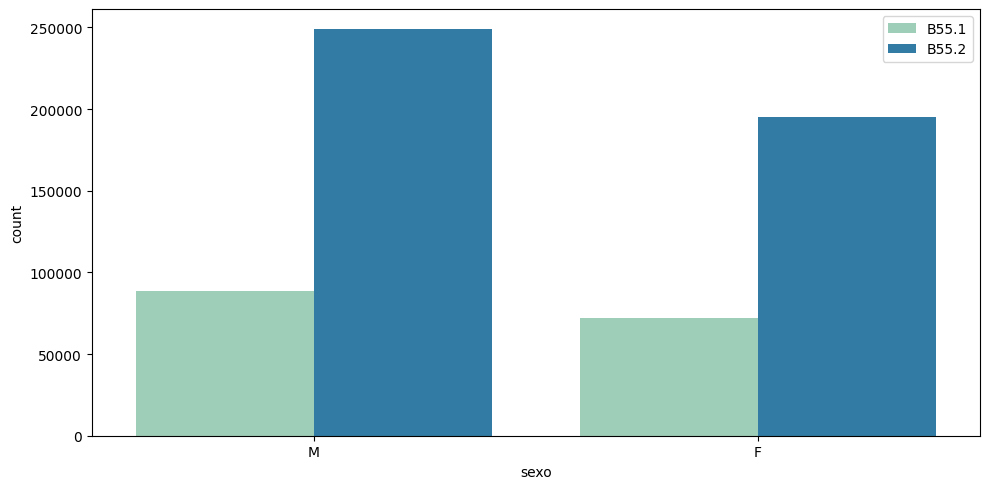

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(df,x="sexo",hue="diagnostic",palette="YlGnBu")
plt.legend(labels=["B55.1","B55.2"])
plt.tight_layout()
plt.show()

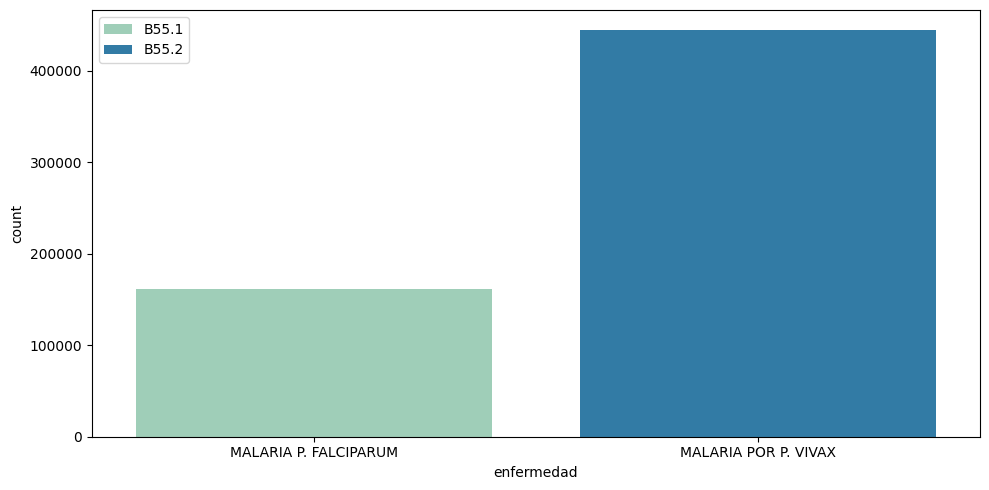

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(df,x="enfermedad",hue="diagnostic",palette="YlGnBu")
plt.legend(labels=["B55.1","B55.2"])
plt.tight_layout()
plt.show()

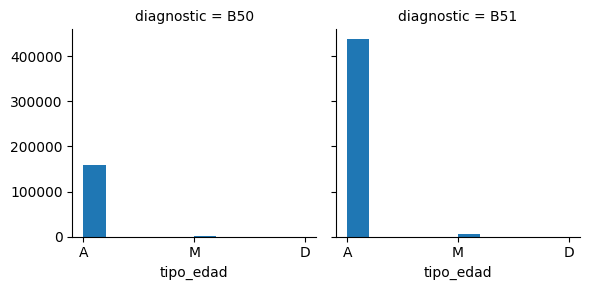

In [ ]:
age=sns.FacetGrid(df,col='diagnostic')
age.map(plt.hist,'tipo_edad')

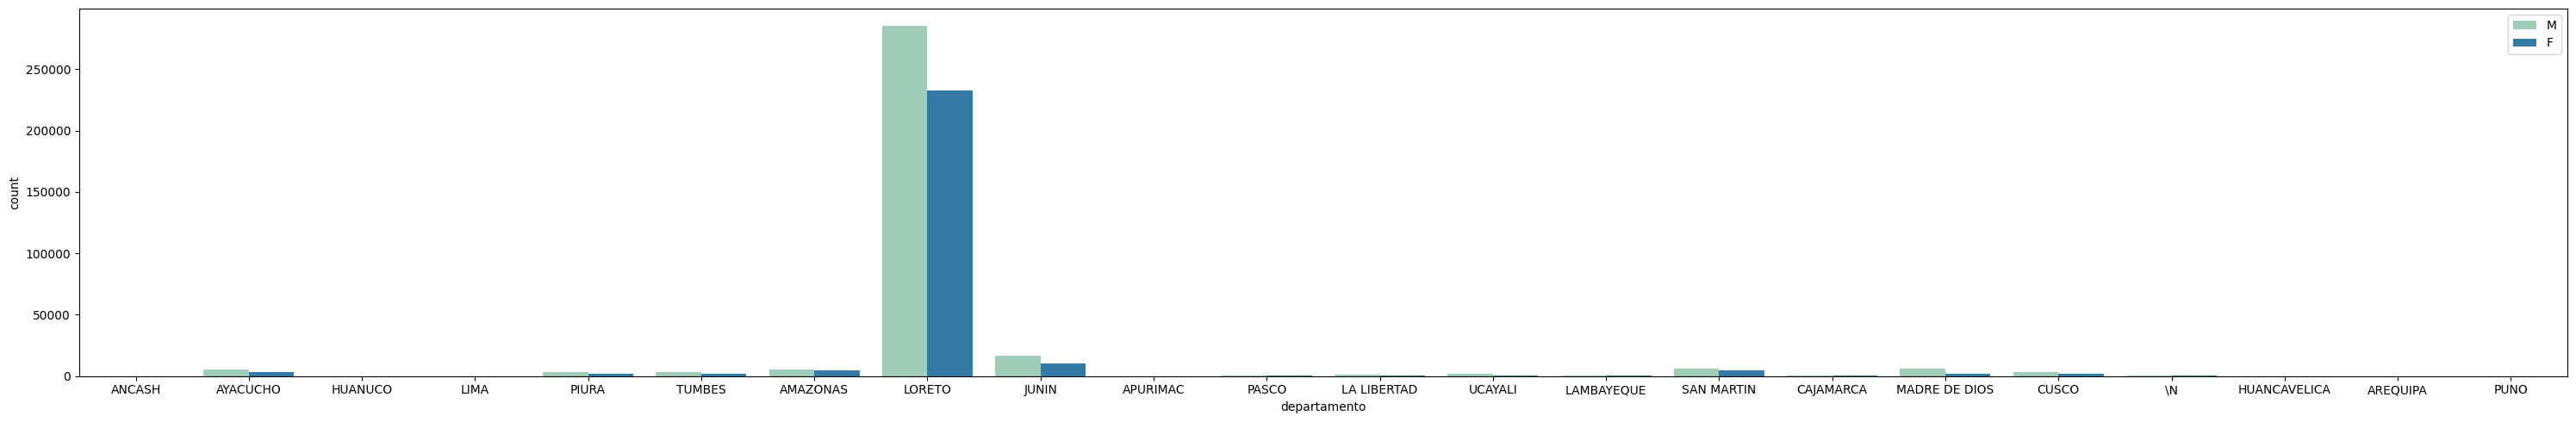

In [ ]:
plt.figure(figsize=(30,5))
sns.countplot(df,x="departamento",hue="sexo",palette="YlGnBu")
plt.legend(labels=["M","F"])
plt.tight_layout()
plt.show()

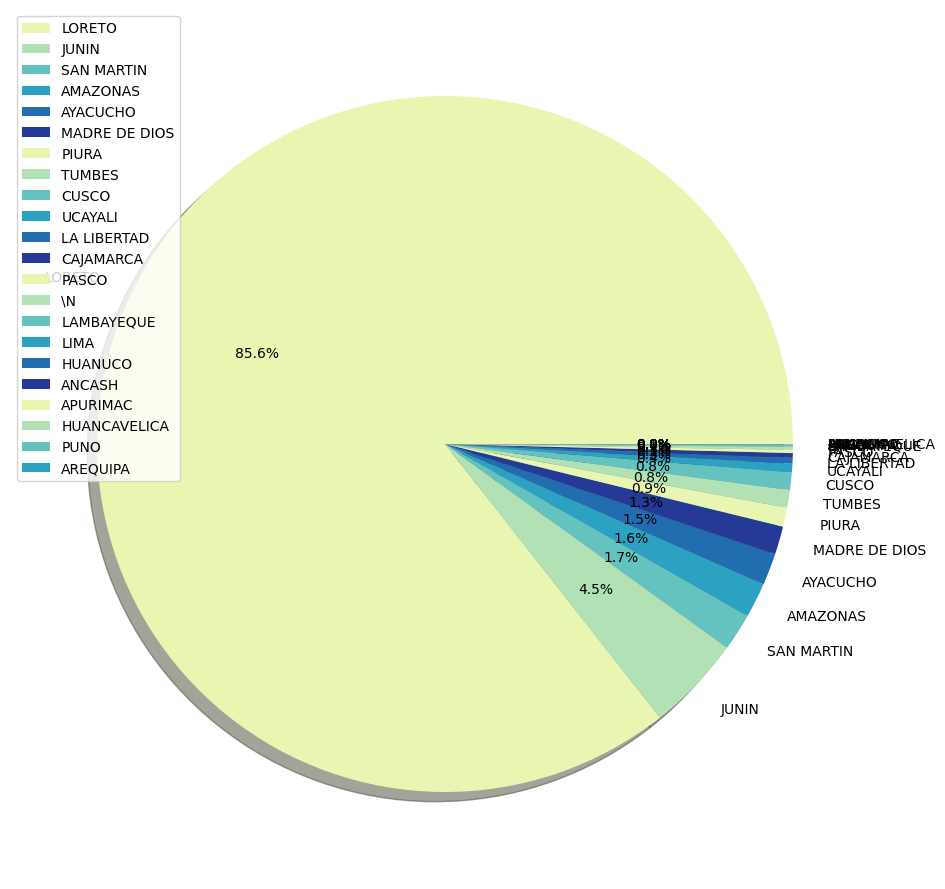

In [ ]:
plt.figure(figsize=(10,9))
x_axis=df["departamento"].value_counts()
figlabels=df["departamento"].value_counts().index
plt.pie(x=x_axis,labels=figlabels,autopct="%0.1f%%",shadow=True,colors=sns.color_palette("YlGnBu"))
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df_loreto = df[data['departamento'] == 'LORETO']
x_axis_loreto = df_loreto['provincia'].value_counts()
figlabels_loreto = df_loreto['provincia'].value_counts().index
plt.figure(figsize=(12, 8))
plt.pie(x=x_axis_loreto, labels=figlabels_loreto, autopct="%0.1f%%", shadow=True, colors=sns.color_palette("Blues"))
plt.legend(title="Provincias de Loreto")
plt.tight_layout()
plt.show()

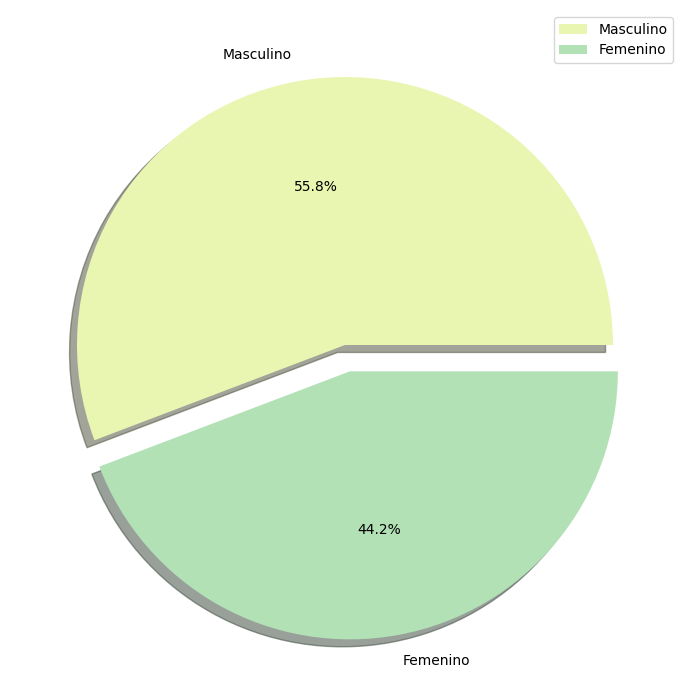

In [ ]:
plt.figure(figsize=(10,7))
x_axis=df["sexo"].value_counts()
figlabels=["Masculino","Femenino"]
plt.pie(x=x_axis,labels=figlabels,autopct="%0.1f%%",explode=[0,0.1],shadow=True,colors=sns.color_palette("YlGnBu"))
plt.legend()
plt.tight_layout()
plt.show()

##**3. Feature Engineering**

En esta etapa, se transforma y prepara los datos para el modelado.

###**Normalización de datos**

In [ ]:
df["departamento"]=LabelEncoder().fit_transform(df["departamento"])
df["sexo"]=LabelEncoder().fit_transform(df["sexo"])

In [ ]:
scaler=MinMaxScaler()

df["diresa"]=scaler.fit_transform(df[["diresa"]].values)
df["edad"]=scaler.fit_transform(df[["edad"]].values)
df["ubigeo"]=scaler.fit_transform(df[["ubigeo"]])

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Trabajo  Final de inteligencia de negocios/Data de panel/datos_abiertos_vigilancia_malaria.csv',
                         encoding="latin-1")

<ipython-input-33-1883f499f501>:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Trabajo  Final de inteligencia de negocios/Data de panel/datos_abiertos_vigilancia_malaria.csv',


###**Codificador de datos**

In [ ]:
lb=LabelEncoder()
df['sexo']=lb.fit_transform(df['sexo'])

In [ ]:
df.head()

,departamento,provincia,distrito,localidad,enfermedad,ano,semana,diagnostic,diresa,ubigeo,localcod,edad,tipo_edad,sexo
0,ANCASH,HUARMEY,HUARMEY,NaN,MALARIA P. FALCIPARUM,2000,6,B50,2,21101,NaN,2,A,1
1,ANCASH,HUARMEY,HUARMEY,NaN,MALARIA P. FALCIPARUM,2000,7,B50,2,21101,NaN,36,A,1
2,ANCASH,HUARMEY,HUARMEY,NaN,MALARIA P. FALCIPARUM,2000,15,B50,2,21101,NaN,7,M,0
3,ANCASH,RECUAY,PARARIN,NaN,MALARIA P. FALCIPARUM,2000,12,B50,2,21708,NaN,23,A,1
4,AYACUCHO,LA MAR,SAN MIGUEL,NaN,MALARIA P. FALCIPARUM,2000,16,B50,5,50501,NaN,17,A,1


In [ ]:
#data = pd.get_dummies(data, columns= ["departamento"])
#data = pd.get_dummies(data, columns= ["sexo"])
#data = pd.get_dummies(data, columns= ["diagnostic"])
#data.head()

In [ ]:
print("Máxima semana: ", df['semana'].max())
print("Mínima semana: ", df['semana'].min())

Máxima semana:  53
Mínima semana:  1


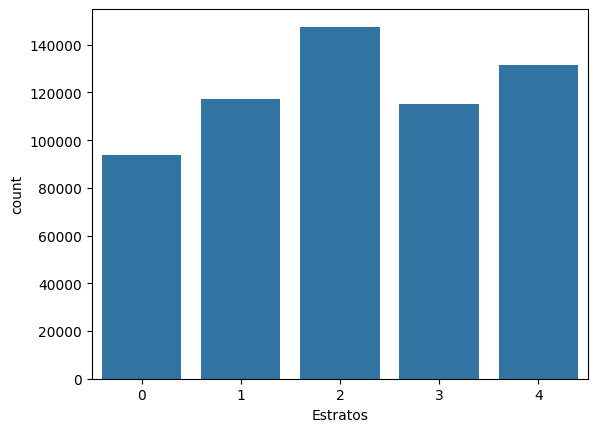

In [ ]:
semana_1 = [0 if i < 10 else 1 if i <20  else 2 if i < 30 else 3 if i < 40 else 4 for i in df["semana"]]
df["Estratos"] = semana_1

sns.countplot(x = "Estratos", data = df)
plt.show()

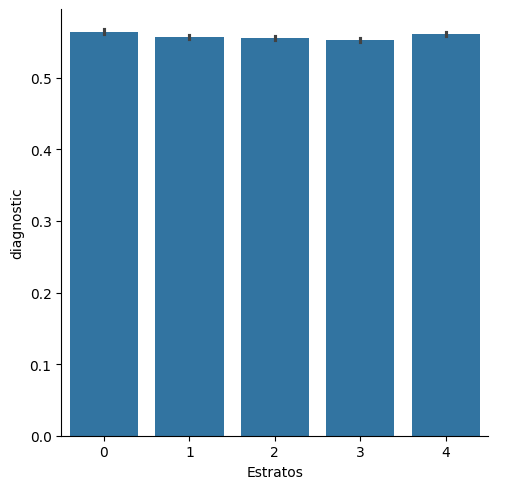

In [ ]:
g = sns.catplot(x = "Estratos", y = "sexo", data = df, kind = "bar")
g.set_ylabels("diagnostic")
plt.show()

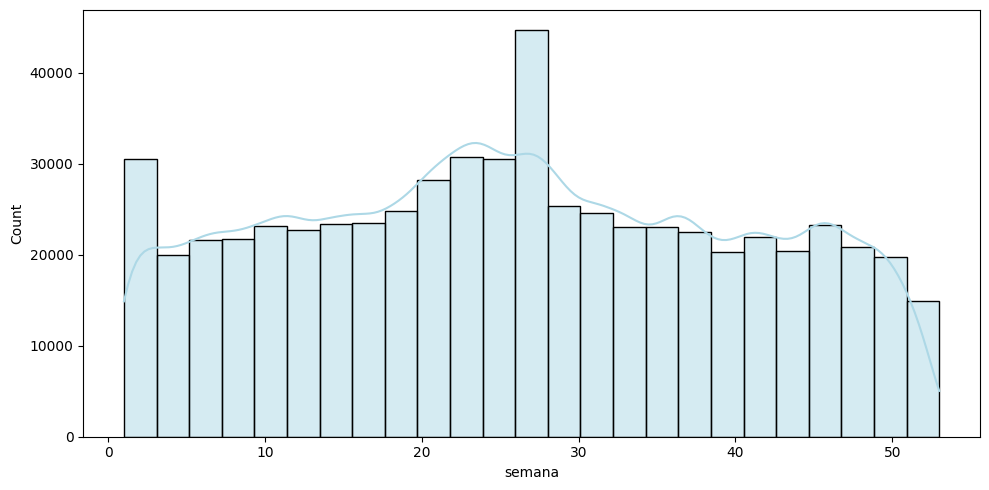

In [ ]:
fig,ax=plt.subplots(figsize=(10,5))
sns.histplot(df["semana"],bins=25,kde=True,color="lightblue",ax=ax)
plt.tight_layout()
plt.show()

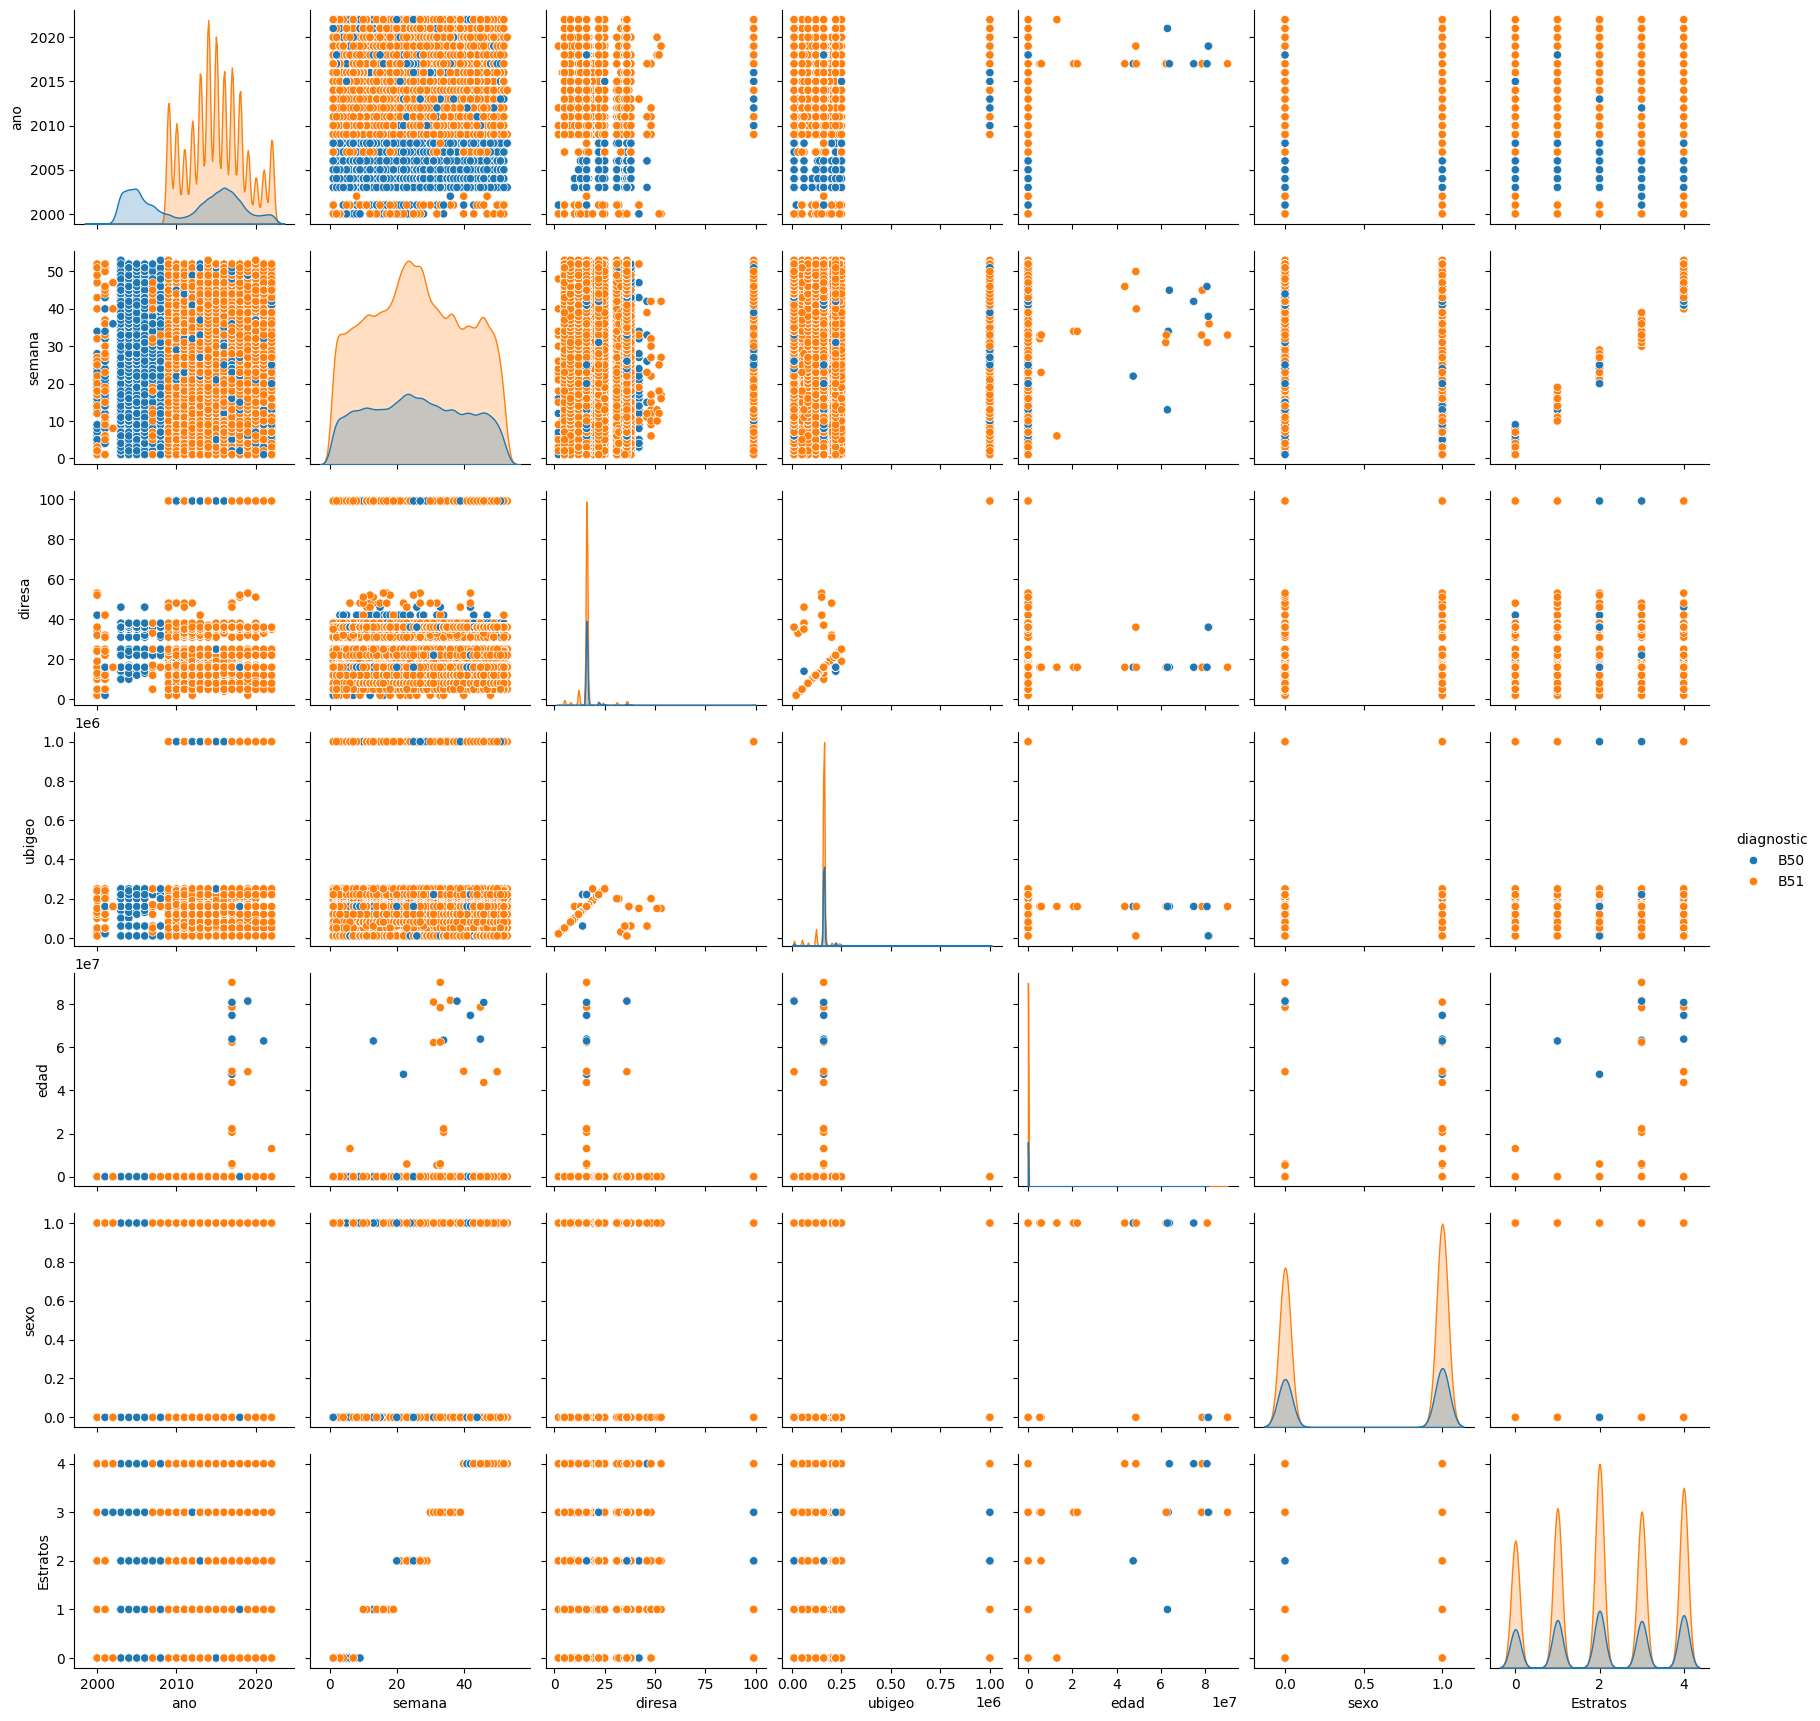

In [ ]:
sns.pairplot(df, hue="diagnostic")
plt.show()

In [ ]:
df.drop(["localidad","provincia","distrito"], axis=1, inplace=True)

In [ ]:
encoder = LabelEncoder()
df["departamento"] = encoder.fit_transform(df["departamento"])
df["sexo"] = encoder.fit_transform(df["sexo"])

<Axes: xlabel='ano'>

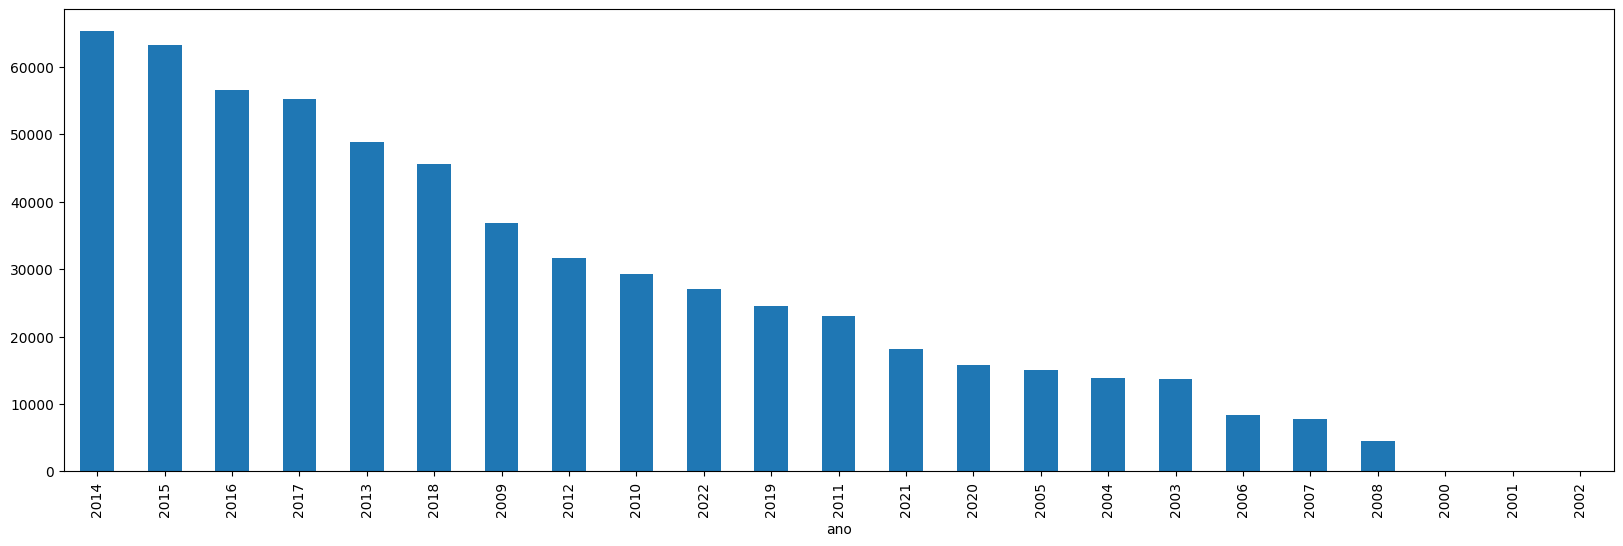

In [ ]:
df["ano"].value_counts().plot.bar(figsize=(20,6))

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)


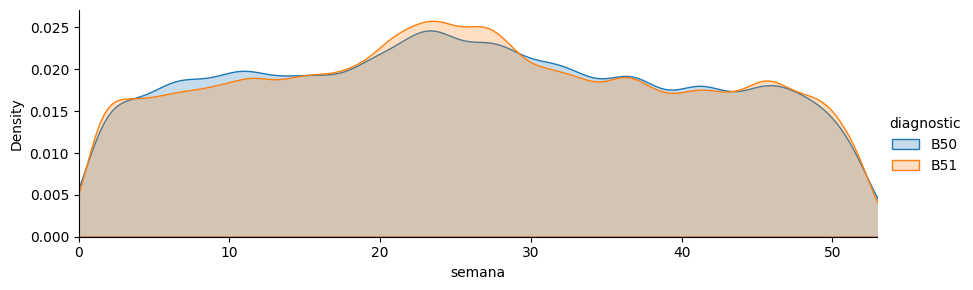

In [ ]:
facet = sns.FacetGrid(df, hue="diagnostic",aspect=3)
facet.map(sns.kdeplot,"semana",shade= True)
facet.set(xlim=(0, df["semana"].max()))
facet.add_legend()

plt.show()

In [ ]:
facet = sns.FacetGrid(df, hue="diagnostic",aspect=3)
facet.map(sns.kdeplot,"diresa",shade= True)
facet.set(xlim=(0, df["diresa"].max()))
facet.add_legend()

plt.show()

In [ ]:
_, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(x = "semana", y = "ano", data = df, hue="diagnostic", ax = ax[0])
sns.scatterplot(x = "semana", y = "diresa", data = df, hue="diagnostic", ax = ax[1])

In [ ]:
facet = sns.FacetGrid(df, hue="diagnostic",aspect=3)
facet.map(sns.kdeplot,"ubigeo",shade= True)
facet.set(xlim=(0, df["ubigeo"].max()))
facet.add_legend()

plt.show()

In [ ]:
plt.figure(figsize=(12,6))
bplot = df.boxplot(patch_artist=True)
plt.xticks(rotation=50)
plt.show()

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(24,18))
axes = axes.flatten()
features = ["departamento","enfermedad","ano","semana","diagnostic","sexo"]
for i in range(len(features)):
    sns.countplot(x=features[i],data=df, palette="Set2",ax=axes[i])

plt.show()

In [ ]:
map_se ={"M":1,"F":1}
df["sexo"]=df["sexo"].map(map_se)
df.head()

In [ ]:
df.loc[ df['edad'] <= 15, 'edad'] = 0
df.loc[(df['edad'] > 15) & (df['edad'] <= 30), 'edad'] = 1
df.loc[(df['edad'] > 30) & (df['edad'] <= 45), 'edad']   = 2
df.loc[ df['edad'] > 45, 'edad'] = 3
df["edad"]=df["edad"].astype(int)
df.head()

In [ ]:
sns.countplot(x="edad",data=df, palette="Set2")